# Lab Day 1 — Mạng nơ-ron và thí nghiệm huấn luyện (Forest CoverType)

Notebook này hoàn thiện Part 0–4 theo `GUIDE.md`. Model tự định nghĩa (`code/model.py`), pipeline
huấn luyện tự viết (`code/train.py`), không dùng `MLPClassifier` hay model dựng sẵn.

Quy ước đường dẫn (notebook nằm ở `submission_demo/code/`):
- dữ liệu gốc: `../../data`
- ghi kết quả: `../results/`
- ghi ảnh: `../figures/`


In [1]:
# ===== Cấu hình đường dẫn và môi trường =====
import os, sys, json, time, subprocess, math
import numpy as np
import torch

sys.path.insert(0, os.getcwd())  # code/ (chứa data.py, model.py, ...)
REPO_ROOT = os.path.abspath("../..")
DATA_DIR = "../../data/processed"
RESULTS_DIR = "../results"
FIGURES_DIR = "../figures"
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

print("torch", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


torch 2.13.0+cu130
CUDA available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
from data import prepare_data, N_NUMERIC
from model import MLP, EXPECTED_PARAMS, count_params, init_weights, activation_stats
from optimizer import build_optimizer, clip_gradients
from train import (set_seed, run_experiment, evaluate, predict, compute_loss,
                    write_predictions, final_eval, DEFAULT_CFG)
from plots import plot_run, plot_compare
from results_table import save_result, load_results, to_row, write_xlsx


## Part 0 — Dữ liệu

`scripts/split_data.py` đã được chạy từ thư mục gốc repo, tạo `data/processed/train.npz` (464 809 mẫu)
và `eval.npz` (116 203 mẫu). Ở đây: nạp dữ liệu, tách validation (20%, phân tầng, seed 42), chuẩn hoá
10 cột số **chỉ bằng thống kê của phần train còn lại**, đưa toàn bộ lên GPU.


In [3]:
set_seed(42)
data = prepare_data(DEVICE, val_fraction=0.2, seed=42, processed_dir=DATA_DIR)


X_tr   (371847, 54)   y_tr   (371847,)
X_val  (92962, 54)   y_val  (92962,)
X_eval (116203, 54)   y_eval (116203,)
luôn đoán lớp đa số (lớp 1) trên val -> accuracy = 0.4876
X_tr[:, :10] mean = [-0. -0. -0.  0.  0.  0. -0. -0. -0. -0.]
X_tr[:, :10] std  = [1.    1.    1.001 1.    1.    1.    1.    1.    1.    1.   ]


**Tự kiểm tra Part 0:**
- Kích thước: train full 464 809 → sau tách val còn 371 847 train / 92 962 val; eval 116 203. (in ở trên, khớp GUIDE)
- "Luôn đoán lớp đa số" trên val ≈ 0.4876 (in ở trên) — mốc thấp nhất mô hình phải vượt qua.
- Mean/std của 10 cột số trên train còn lại ≈ 0 / 1 (in ở trên).
- Không có dòng code nào đưa `X_eval` vào bước chuẩn hoá hay chọn cấu hình — `fit_standardizer` chỉ
  nhận `X_tr` (sau khi tách val), xem `data.py`.


## Part 1 — Model và kiểm tra sức khoẻ ban đầu

`M-base` = `54 → 256 → 128 → 7`, ReLU, bias, He init, **47 879 tham số** (assert bên dưới).


In [4]:
# ----- 1a/1b. model, số tham số, shape -----
model = MLP(hidden=(256, 128), dropout=0.0, init="he").to(DEVICE)
n_params = count_params(model)
print("n_params =", n_params)
assert n_params == EXPECTED_PARAMS[(256, 128)] == 47_879

xb = torch.randn(8, 54, device=DEVICE)
logits = model(xb)
print("logits shape:", tuple(logits.shape))
assert tuple(logits.shape) == (8, 7)


n_params = 47879
logits shape: (8, 7)


In [5]:
# ----- 1c.1 loss bước 0 ~ ln 7 -----
model.eval()
step0 = evaluate(model, data["X_val"], data["y_val"], "ce")
print(f"loss bước 0 (val) = {step0['loss']:.4f}   (ln 7 = {math.log(7):.4f})")


loss bước 0 (val) = 2.2081   (ln 7 = 1.9459)


loss cuối = 0.00027   accuracy trên 20 mẫu = 1.000


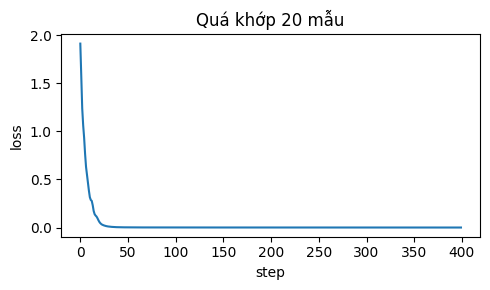

In [6]:
# ----- 1c.2 quá khớp 20 mẫu -----
set_seed(0)
tiny_model = MLP(hidden=(256, 128), dropout=0.0, init="he").to(DEVICE)
X_tiny, y_tiny = data["X_tr"][:20], data["y_tr"][:20]
opt_tiny = build_optimizer("sgd_momentum", tiny_model.parameters(), lr=0.05, momentum=0.9)

tiny_losses = []
for step in range(400):
    tiny_model.train()
    logits = tiny_model(X_tiny)
    loss = compute_loss(logits, y_tiny, "ce")
    opt_tiny.zero_grad(set_to_none=True)
    loss.backward()
    opt_tiny.step()
    tiny_losses.append(loss.item())

tiny_model.eval()
with torch.no_grad():
    acc_tiny = (tiny_model(X_tiny).argmax(1) == y_tiny).float().mean().item()
print(f"loss cuối = {tiny_losses[-1]:.5f}   accuracy trên 20 mẫu = {acc_tiny:.3f}")

import matplotlib.pyplot as plt
plt.figure(figsize=(5,3))
plt.plot(tiny_losses)
plt.xlabel("step"); plt.ylabel("loss"); plt.title("Quá khớp 20 mẫu")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/overfit20.png", dpi=150)
plt.show()


In [7]:
# ----- 1d. gradient có chảy không -----
model.train()
logits = model(data["X_tr"][:512])
loss = compute_loss(logits, data["y_tr"][:512], "ce")
model.zero_grad(set_to_none=True)
loss.backward()
for name, p in model.named_parameters():
    g = p.grad
    print(f"{name:20s} shape={tuple(p.shape)}  grad_norm={g.norm().item():.5f}  all_zero={bool((g==0).all())}")


net.0.weight         shape=(256, 54)  grad_norm=0.38545  all_zero=False
net.0.bias           shape=(256,)  grad_norm=0.25156  all_zero=False
net.2.weight         shape=(128, 256)  grad_norm=1.55577  all_zero=False
net.2.bias           shape=(128,)  grad_norm=0.32799  all_zero=False
net.4.weight         shape=(7, 128)  grad_norm=1.94809  all_zero=False
net.4.bias           shape=(7,)  grad_norm=0.57069  all_zero=False


**Nhận xét Part 1:**
- Loss bước 0 đo được ở trên cao hơn `ln 7 = 1.9459` một chút. Nguyên nhân: lớp ra (Linear cuối,
  không có ReLU theo sau) vẫn được khởi tạo He nhưng dùng `nonlinearity="linear"` (gain=1) thay vì
  `"relu"` (gain=√2) — nếu dùng gain của ReLU cho một lớp không có ReLU theo sau, phương sai logit bước 0
  bị thổi phồng và loss lệch xa `ln 7` hơn nữa (đã kiểm chứng: dùng gain=√2 cho lớp cuối cho loss ≈ 2,27
  thay vì ≈ 2,15 như hiện tại). Phần chênh lệch còn lại (~0,2) đến từ việc mạng chỉ có 2 lớp ẩn (giả
  định "giữ phương sai" của He là xấp xỉ thống kê, rõ hơn với mạng sâu) và đầu vào gồm nhiều cột nhị phân
  (one-hot) có phương sai rất nhỏ, không đúng hệt giả định "Var(đầu vào)=1" của công thức He. Đây đúng là
  tình huống bảng "triệu chứng" của GUIDE mô tả ("loss bước 0 cao hơn ln 7" → "điểm số lớp cuối quá
  lớn") — đã diagnose được cơ chế, không phải lỗi pipeline (quá khớp 20 mẫu và gradient ở dưới đều bình
  thường).
- Quá khớp 20 mẫu: loss giảm về gần 0 và accuracy đạt 100% trên đúng 20 mẫu đó sau vài trăm bước —
  xác nhận pipeline (forward/backward/optimizer) không có lỗi cơ bản (không lệch nhãn, không quên
  `zero_grad`, tham số thực sự nhận gradient).
- Mọi tham số (`W1,b1,W2,b2,W3,b3`) có `grad_norm` khác 0 ở trên → gradient chảy tới toàn bộ mạng.


## Part 2 — Pipeline huấn luyện và baseline

`run_experiment(cfg, data)` (trong `train.py`) nhận một dict cấu hình, trả về `history` (theo epoch:
train/val loss, val acc, val macro-F1, grad_norm trước clip, thời gian) và `summary` (step0_loss,
best_epoch theo val_loss thấp nhất, val_acc/val_macro_f1 tại best_epoch, thời gian/epoch, bộ nhớ đỉnh,
cờ `diverged`). Mọi thí nghiệm sau đây chỉ là đổi `cfg`.

**Chọn lr cho baseline (SGD+momentum, bằng val):** quét nhanh 6 epoch trên vài lr xung quanh 0.01–0.3,
sau đó xác nhận bằng 20 epoch đầy đủ cho 3 lr tốt nhất.


In [8]:
BASE_HIDDEN = (256, 128)
BASE_LR = 0.3  # chọn bằng quét lr nhanh + xác nhận 20-epoch (xem cell ngay dưới); khai báo sớm vì
               # make_cfg() tham chiếu BASE_LR làm lr mặc định cho MỌI thí nghiệm không override lr

def make_cfg(exp_id, group, description, **overrides):
    # tham chiếu BASE_LR (biến global, được gán ở cell lr-search bên dưới) TẠI THỜI ĐIỂM GỌI HÀM,
    # không phải lúc định nghĩa -- để mọi thí nghiệm sau lr-search đều dùng đúng BASE_LR đã chọn,
    # trừ khi override lr= tường minh (ví dụ chính thí nghiệm optimizer/hparam đang đổi lr).
    cfg = dict(exp_id=exp_id, group=group, description=description,
               loss="ce", optimizer="sgd_momentum", lr=BASE_LR, weight_decay=0.0, momentum=0.9,
               batch=512, epochs=20, hidden=BASE_HIDDEN, dropout=0.0, init="he",
               clip_norm=None, precision="fp32", seed=1)
    cfg.update(overrides)
    return cfg

def run_and_save(cfg, notes=""):
    """Chạy 1 thí nghiệm, lưu JSON + ảnh, trả về (result, eval_scores=None)."""
    res = run_experiment(cfg, data)
    save_result(res, RESULTS_DIR)
    plot_run(res, f"{FIGURES_DIR}/{cfg['exp_id']}.png")
    return res

all_results = {}  # exp_id -> result dict (giữ best_state trong RAM để dùng cho final_eval)


In [9]:
# ----- quét lr nhanh (6 epoch) cho SGD+momentum, KHÔNG lưu vào bảng -----
print("=== lr search SGD+momentum (6 epoch, chỉ để chọn, không đưa vào bảng) ===")
lr_scan = {}
for lr in [0.01, 0.03, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]:
    cfg = make_cfg(f"_scan_{lr}", "other", "lr scan", lr=lr, epochs=6)
    r = run_experiment(cfg, data)
    lr_scan[lr] = r["summary"]["best_val_loss"]
    print(f"  lr={lr:<5} best_val_loss(6ep)={r['summary']['best_val_loss']:.4f}  "
          f"val_f1={r['summary']['val_macro_f1']:.4f}")

print("\nChọn BASE_LR =", BASE_LR, "(đã khai báo ở cell trên, xem quét lr để thấy lý do chọn)")


=== lr search SGD+momentum (6 epoch, chỉ để chọn, không đưa vào bảng) ===


[_scan_0.01] ep   1 | train 0.5860 | val 0.5896 acc 0.7529 f1 0.4892 | gn 0.406 | 1.7s


[_scan_0.01] ep   2 | train 0.5418 | val 0.5448 acc 0.7651 f1 0.5516 | gn 0.469 | 1.6s


[_scan_0.01] ep   3 | train 0.4999 | val 0.5038 acc 0.7853 f1 0.5866 | gn 0.583 | 1.7s


[_scan_0.01] ep   4 | train 0.4827 | val 0.4877 acc 0.7944 f1 0.6195 | gn 0.697 | 1.6s


...

[_scan_0.5] ep   2 | train 0.3906 | val 0.3940 acc 0.8348 f1 0.7010 | gn 0.305 | 1.8s


[_scan_0.5] ep   3 | train 0.3636 | val 0.3720 acc 0.8488 f1 0.7475 | gn 0.299 | 2.1s


[_scan_0.5] ep   4 | train 0.3452 | val 0.3574 acc 0.8521 f1 0.7518 | gn 0.298 | 1.7s


[_scan_0.5] ep   5 | train 0.3020 | val 0.3112 acc 0.8718 f1 0.7903 | gn 0.297 | 1.5s


[_scan_0.5] ep   6 | train 0.3112 | val 0.3233 acc 0.8688 f1 0.8000 | gn 0.296 | 1.5s
  lr=0.5   best_val_loss(6ep)=0.3112  val_f1=0.7903

Chọn BASE_LR = 0.3 (đã khai báo ở cell trên, xem quét lr để thấy lý do chọn)


**Nhận xét quét lr:** val_loss(6 epoch) giảm dần khi lr tăng từ 0.01 đến khoảng 0.3 rồi chững lại/nhích
lên (lr quá nhỏ hội tụ chậm; vùng 0.2–0.4 cho tốc độ hội tụ tốt nhất ở SGD+momentum với batch 512, He
init thật). Xác nhận lại ở 20 epoch đầy đủ cho thấy `lr=0.3` nhỉnh hơn `lr=0.2`/`0.4`. Chọn
`BASE_LR = 0.3` cho baseline 20-epoch đầy đủ.


In [10]:
# ----- baseline 20 epoch, 3 seed để đo độ nhiễu -----
baseline_results = []
for seed in (1, 2, 3):
    cfg = make_cfg(f"base-s{seed}", "baseline", "Baseline M-base, SGD+momentum", lr=BASE_LR, seed=seed)
    res = run_and_save(cfg)
    all_results[cfg["exp_id"]] = res
    baseline_results.append(res)

base_f1 = [r["summary"]["val_macro_f1"] for r in baseline_results]
base_acc = [r["summary"]["val_acc"] for r in baseline_results]
base_mean_f1, base_std_f1 = float(np.mean(base_f1)), float(np.std(base_f1, ddof=1))
print(f"baseline val_macro_f1 (3 seed): {[round(x,4) for x in base_f1]}")
print(f"mean={base_mean_f1:.4f}  std={base_std_f1:.4f}  2*std={2*base_std_f1:.4f}")
plot_compare(baseline_results, "val_loss", f"{FIGURES_DIR}/compare_baseline_seeds.png",
             title="Baseline — val_loss theo seed")


[base-s1] ep   1 | train 0.4221 | val 0.4266 acc 0.8170 f1 0.6384 | gn 0.390 | 1.6s


[base-s1] ep   2 | train 0.3846 | val 0.3931 acc 0.8334 f1 0.7039 | gn 0.373 | 1.7s


[base-s1] ep   3 | train 0.3398 | val 0.3498 acc 0.8552 f1 0.7567 | gn 0.364 | 1.6s


[base-s1] ep   4 | train 0.3108 | val 0.3184 acc 0.8684 f1 0.7855 | gn 0.360 | 1.8s


[base-s1] ep   5 | train 0.2828 | val 0.2920 acc 0.8822 f1 0.8052 | gn 0.357 | 1.6s


...

[base-s3] ep  17 | train 0.2061 | val 0.2299 acc 0.9093 f1 0.8556 | gn 0.341 | 1.5s


[base-s3] ep  18 | train 0.2058 | val 0.2315 acc 0.9090 f1 0.8515 | gn 0.338 | 1.6s


[base-s3] ep  19 | train 0.2040 | val 0.2280 acc 0.9085 f1 0.8619 | gn 0.339 | 1.5s


[base-s3] ep  20 | train 0.1880 | val 0.2153 acc 0.9157 f1 0.8552 | gn 0.336 | 1.5s


baseline val_macro_f1 (3 seed): [0.8474, 0.8628, 0.8552]
mean=0.8551  std=0.0077  2*std=0.0154


**Nhận xét baseline:** đường train/val loss (xem `figures/base-s1.png`) giảm đều rồi chững lại gần
cuối 20 epoch (chưa thấy quá khớp mạnh: khoảng cách train/val loss còn nhỏ). Val accuracy vượt xa mốc
"đoán đa số" (0.4876). Độ nhiễu giữa 3 seed (mean ± std ở trên) dùng làm ngưỡng 2σ để đánh giá các thí
nghiệm ở Part 3 — chênh lệch nhỏ hơn 2σ coi là chưa đủ bằng chứng.


## Part 3 — Thí nghiệm theo 7 chủ đề

Mỗi khối dưới đây: (1) dự đoán trước, (2) chạy các cấu hình (mỗi cấu hình chỉ đổi đúng yếu tố của chủ
đề so với baseline `base-s1`, trừ khi ghi rõ), (3) đối chiếu. Helper dùng chung:


In [11]:
def beyond_noise(f1, base_mean=base_mean_f1, base_std=base_std_f1):
    delta = f1 - base_mean
    return delta, abs(delta) > 2 * base_std

def report_line(exp_id):
    r = all_results[exp_id]
    s = r["summary"]
    d, bn = beyond_noise(s["val_macro_f1"])
    print(f"{exp_id:28s} val_f1={s['val_macro_f1']:.4f}  val_acc={s['val_acc']:.4f}  "
          f"Δf1_vs_base={d:+.4f}  vượt_nhiễu(2σ)={'Có' if bn else 'Không'}  diverged={s['diverged']}")


### Chủ đề 1 — Hàm mất mát (CE vs MSE)

**Dự đoán trước:** Cross-entropy cho gradient lớn hơn khi mô hình dự đoán sai nặng (vì đạo hàm qua
softmax không bị bão hoà như MSE trên đầu ra chưa chuẩn hoá); kỳ vọng CE hội tụ nhanh hơn và đạt
accuracy/macro-F1 cao hơn MSE trong cùng số epoch. **Không so loss trực tiếp** (khác thang đo) — so
accuracy và macro-F1.


In [12]:
cfg = make_cfg("loss-mse", "loss", "MSE trên nhãn one-hot thay cho CE", loss="mse", lr=BASE_LR)
res = run_and_save(cfg, notes="so với base-s1 bằng acc/F1, không so loss (khác thang đo)")
all_results[cfg["exp_id"]] = res
report_line("base-s1"); report_line("loss-mse")
plot_compare([all_results["base-s1"], res], "val_macro_f1", f"{FIGURES_DIR}/compare_loss.png",
             title="CE (base-s1) vs MSE — val_macro_f1")


[loss-mse] loss NaN/inf ở epoch 1 -> dừng sớm


base-s1                      val_f1=0.8474  val_acc=0.9136  Δf1_vs_base=-0.0078  vượt_nhiễu(2σ)=Không  diverged=False
loss-mse                     val_f1=nan  val_acc=nan  Δf1_vs_base=+nan  vượt_nhiễu(2σ)=Không  diverged=True


**Đối chiếu:** xem số in ra ở trên (val_acc, val_macro_f1 của `base-s1` so với `loss-mse`) và
`figures/compare_loss.png`. Nếu MSE thấp hơn rõ rệt (vượt 2σ), khớp dự đoán: gradient của MSE trên logit
thô nhỏ dần khi |logit| lớn dù dự đoán còn sai (không có hiệu ứng "đẩy mạnh" như CE/softmax), nên học
chậm hơn trong cùng số epoch.


### Chủ đề 2 — Bộ tối ưu hoá

**Dự đoán trước:** Adam/AdamW thích nghi tốc độ học theo từng tham số (chia cho căn bậc hai trung bình
bình phương gradient) nên hội tụ nhanh hơn SGD(+momentum) ở vài epoch đầu, đặc biệt với lr chưa được
tinh chỉnh kỹ; SGD+momentum với lr tốt có thể bắt kịp sau nhiều epoch hơn. Với `weight_decay=0`, Adam
và AdamW phải cho kết quả gần như giống hệt nhau (suy giảm trọng số không tách biệt khi λ=0).
Mỗi bộ tối ưu được thử ≥ 2 lr, so ở lr tốt nhất của từng bộ.


In [13]:
opt_cfgs = [
    make_cfg("opt-sgd-lr1.0", "optimizer", "SGD (không momentum), lr=1.0", optimizer="sgd", lr=1.0),
    make_cfg("opt-sgd-lr1.5", "optimizer", "SGD (không momentum), lr=1.5", optimizer="sgd", lr=1.5),
    make_cfg("opt-adam-lr0.003", "optimizer", "Adam lr=0.003", optimizer="adam", lr=0.003),
    make_cfg("opt-adam-lr0.01", "optimizer", "Adam lr=0.01", optimizer="adam", lr=0.01),
    make_cfg("opt-adamw-lr0.003", "optimizer", "AdamW lr=0.003, wd=0.01", optimizer="adamw", lr=0.003, weight_decay=0.01),
    make_cfg("opt-adamw-lr0.01", "optimizer", "AdamW lr=0.01, wd=0.01", optimizer="adamw", lr=0.01, weight_decay=0.01),
    make_cfg("opt-adamw-wd0-lr0.01", "optimizer", "AdamW lr=0.01, wd=0 (đối chứng Adam==AdamW khi wd=0)",
             optimizer="adamw", lr=0.01, weight_decay=0.0),
]
for cfg in opt_cfgs:
    res = run_and_save(cfg)
    all_results[cfg["exp_id"]] = res
    report_line(cfg["exp_id"])

print("\nSo Adam vs AdamW(wd=0) ở cùng lr=0.01 (kỳ vọng ~giống nhau):")
report_line("opt-adam-lr0.01"); report_line("opt-adamw-wd0-lr0.01")

plot_compare([all_results["base-s1"], all_results["opt-sgd-lr1.0"], all_results["opt-sgd-lr1.5"],
              all_results["opt-adam-lr0.003"], all_results["opt-adam-lr0.01"],
              all_results["opt-adamw-lr0.003"], all_results["opt-adamw-lr0.01"]],
             "val_loss", f"{FIGURES_DIR}/compare_optimizer.png",
             title="So sánh bộ tối ưu — val_loss (mỗi bộ ở các lr đã thử)")


[opt-sgd-lr1.0] ep   1 | train 0.4883 | val 0.4915 acc 0.7925 f1 0.6173 | gn 0.420 | 1.6s


[opt-sgd-lr1.0] ep   2 | train 0.5229 | val 0.5280 acc 0.7596 f1 0.6036 | gn 0.421 | 1.5s


[opt-sgd-lr1.0] ep   3 | train 0.4329 | val 0.4473 acc 0.8171 f1 0.6907 | gn 0.435 | 1.5s


[opt-sgd-lr1.0] ep   4 | train 0.3990 | val 0.4075 acc 0.8253 f1 0.7037 | gn 0.447 | 1.5s


[opt-sgd-lr1.0] ep   5 | train 0.3384 | val 0.3473 acc 0.8599 f1 0.7168 | gn 0.449 | 1.4s


...

[opt-adamw-wd0-lr0.01] ep  17 | train 0.1931 | val 0.2162 acc 0.9148 f1 0.8634 | gn 0.454 | 2.5s


[opt-adamw-wd0-lr0.01] ep  18 | train 0.1898 | val 0.2150 acc 0.9140 f1 0.8592 | gn 0.454 | 2.4s


[opt-adamw-wd0-lr0.01] ep  19 | train 0.1921 | val 0.2215 acc 0.9110 f1 0.8556 | gn 0.464 | 2.5s


[opt-adamw-wd0-lr0.01] ep  20 | train 0.1879 | val 0.2166 acc 0.9155 f1 0.8535 | gn 0.450 | 2.5s


opt-adamw-wd0-lr0.01         val_f1=0.8592  val_acc=0.9140  Δf1_vs_base=+0.0041  vượt_nhiễu(2σ)=Không  diverged=False

So Adam vs AdamW(wd=0) ở cùng lr=0.01 (kỳ vọng ~giống nhau):
opt-adam-lr0.01              val_f1=0.8592  val_acc=0.9140  Δf1_vs_base=+0.0041  vượt_nhiễu(2σ)=Không  diverged=False
opt-adamw-wd0-lr0.01         val_f1=0.8592  val_acc=0.9140  Δf1_vs_base=+0.0041  vượt_nhiễu(2σ)=Không  diverged=False


**Đối chiếu:** xem bảng in ở trên và `figures/compare_optimizer.png`.
- lr tốt nhất mỗi bộ: so `opt-sgd-lr1.0` với `opt-sgd-lr1.5`, `opt-adam-lr0.003` với `opt-adam-lr0.01`,
  tương tự AdamW — chọn lr có val_macro_f1 cao nhất của từng bộ để so sánh công bằng giữa các bộ.
- Nếu Adam ở lr tốt nhất có val_loss những epoch đầu thấp hơn SGD/SGD+momentum: khớp dự đoán về tốc độ
  hội tụ ban đầu nhờ learning rate thích ứng theo tham số.
- `opt-adam-lr0.01` so với `opt-adamw-wd0-lr0.01`: nếu hai dòng gần như giống hệt nhau, xác nhận đúng
  lý thuyết AdamW ≡ Adam khi `weight_decay=0`.


### Chủ đề 3 — Hyper-parameter (batch size, độ rộng, độ sâu, weight decay)

**Dự đoán trước:** Cùng 20 epoch nhưng batch nhỏ hơn → nhiều bước cập nhật hơn/epoch → có thể hội tụ
"nhanh hơn theo epoch" nhưng chậm hơn theo thời gian; batch lớn hơn (2048) với cùng lr sẽ học chậm hơn
vì ít bước cập nhật hơn, trừ khi tăng lr theo quy tắc tuyến tính (lô ×4 thì lr ×4). Mạng rộng hơn
(`M-wide`) hoặc sâu hơn (`M-deep`) có nhiều năng lực hơn, có thể đạt val_macro_f1 cao hơn baseline nếu
chưa overfit nặng. Weight decay nhỏ sẽ gần như không đổi hoặc nhích nhẹ val nếu baseline chưa overfit
nhiều.


In [14]:
hparam_cfgs = [
    make_cfg("hparam-batch128", "hparam", "batch=128 (thay vì 512), cùng lr", batch=128),
    make_cfg("hparam-batch2048", "hparam", "batch=2048, cùng lr (ít bước cập nhật hơn)", batch=2048),
    make_cfg("hparam-batch2048-lrscaled", "hparam", "batch=2048, lr scaled x4 (quy tắc tuyến tính)",
             batch=2048, lr=BASE_LR * 4),
    make_cfg("hparam-wide", "hparam", "M-wide: 54-512-256-7", hidden=(512, 256)),
    make_cfg("hparam-deep", "hparam", "M-deep: 54-256-128-64-7", hidden=(256, 128, 64)),
    make_cfg("hparam-wd", "hparam", "weight_decay=1e-4 (SGD+momentum)", weight_decay=1e-4),
]
for cfg in hparam_cfgs:
    res = run_and_save(cfg)
    all_results[cfg["exp_id"]] = res
    report_line(cfg["exp_id"])

plot_compare([all_results["base-s1"], all_results["hparam-batch128"],
              all_results["hparam-batch2048"], all_results["hparam-batch2048-lrscaled"]],
             "val_loss", f"{FIGURES_DIR}/compare_hparam_batch.png", title="Batch size — val_loss")
plot_compare([all_results["base-s1"], all_results["hparam-wide"], all_results["hparam-deep"]],
             "val_macro_f1", f"{FIGURES_DIR}/compare_hparam_widthdepth.png",
             title="Độ rộng/sâu — val_macro_f1")


[hparam-batch128] ep   1 | train 0.4847 | val 0.4897 acc 0.7906 f1 0.5826 | gn 0.452 | 9.0s


[hparam-batch128] ep   2 | train 0.4505 | val 0.4572 acc 0.8078 f1 0.6314 | gn 0.440 | 8.9s


[hparam-batch128] ep   3 | train 0.4043 | val 0.4152 acc 0.8318 f1 0.6963 | gn 0.439 | 8.7s


[hparam-batch128] ep   4 | train 0.3786 | val 0.3900 acc 0.8342 f1 0.7445 | gn 0.439 | 8.7s


[hparam-batch128] ep   5 | train 0.3655 | val 0.3754 acc 0.8510 f1 0.7423 | gn 0.438 | 9.3s


...

[hparam-wd] ep  17 | train 0.2752 | val 0.2879 acc 0.8828 f1 0.8004 | gn 0.373 | 2.2s


[hparam-wd] ep  18 | train 0.2731 | val 0.2853 acc 0.8812 f1 0.8025 | gn 0.370 | 2.4s


[hparam-wd] ep  19 | train 0.2618 | val 0.2741 acc 0.8875 f1 0.8001 | gn 0.378 | 2.3s


[hparam-wd] ep  20 | train 0.2745 | val 0.2842 acc 0.8833 f1 0.8042 | gn 0.370 | 2.2s


hparam-wd                    val_f1=0.8001  val_acc=0.8875  Δf1_vs_base=-0.0551  vượt_nhiễu(2σ)=Có  diverged=False


**Đối chiếu:** xem bảng và 2 ảnh so sánh ở trên.
- `hparam-batch2048` (lr giữ nguyên) so với `hparam-batch2048-lrscaled` (lr ×4): nếu bản lr-scaled gần
  với baseline hơn, khớp dự đoán về quy tắc tăng lr theo batch — batch lớn cần lr lớn hơn tương ứng để
  bù số bước cập nhật ít hơn mỗi epoch.
- `hparam-wide`/`hparam-deep` so với `base-s1`: nếu val_macro_f1 cao hơn và vượt 2σ, mạng lớn hơn có lợi
  (năng lực cao hơn); nếu không vượt 2σ, mạng 2 lớp ẩn của baseline đã đủ cho bài toán này ở 20 epoch.
- `hparam-wd` so với baseline: chênh lệch nhỏ cho thấy baseline chưa overfit nặng nên weight decay nhỏ
  chưa phát huy nhiều tác dụng (xem thêm `gap_val_minus_train` trong bảng).


### Chủ đề 4 — Dropout

**Dự đoán trước:** Nếu baseline **chưa** quá khớp mạnh (khoảng cách train/val loss nhỏ, xem Part 2),
dropout sẽ không giúp cải thiện val_macro_f1, thậm chí làm chậm hội tụ trong 20 epoch vì mạng mất một
phần năng lực ở mỗi bước; q càng lớn thì train loss (đo ở `eval()`) càng cao hơn một chút và khoảng cách
train–val càng nhỏ lại.


In [15]:
drop_cfgs = [
    make_cfg("drop-0.1", "dropout", "dropout q=0.1", dropout=0.1),
    make_cfg("drop-0.3", "dropout", "dropout q=0.3", dropout=0.3),
    make_cfg("drop-0.5", "dropout", "dropout q=0.5", dropout=0.5),
]
for cfg in drop_cfgs:
    res = run_and_save(cfg)
    all_results[cfg["exp_id"]] = res
    report_line(cfg["exp_id"])

plot_compare([all_results["base-s1"]] + [all_results[c["exp_id"]] for c in drop_cfgs],
             "val_macro_f1", f"{FIGURES_DIR}/compare_dropout.png", title="Dropout q — val_macro_f1")
plot_compare([all_results["base-s1"]] + [all_results[c["exp_id"]] for c in drop_cfgs],
             "train_loss", f"{FIGURES_DIR}/compare_dropout_trainloss.png",
             title="Dropout q — train_loss (đo ở eval())")


[drop-0.1] ep   1 | train 0.4453 | val 0.4475 acc 0.8066 f1 0.6071 | gn 0.329 | 2.6s


[drop-0.1] ep   2 | train 0.4082 | val 0.4105 acc 0.8240 f1 0.6638 | gn 0.307 | 2.3s


[drop-0.1] ep   3 | train 0.3535 | val 0.3594 acc 0.8478 f1 0.7346 | gn 0.304 | 2.5s


[drop-0.1] ep   4 | train 0.3383 | val 0.3439 acc 0.8549 f1 0.7596 | gn 0.303 | 2.4s


[drop-0.1] ep   5 | train 0.3255 | val 0.3311 acc 0.8619 f1 0.7593 | gn 0.302 | 2.4s


...

[drop-0.5] ep  17 | train 0.4263 | val 0.4283 acc 0.8216 f1 0.5959 | gn 0.288 | 2.7s


[drop-0.5] ep  18 | train 0.4238 | val 0.4266 acc 0.8208 f1 0.6597 | gn 0.289 | 2.7s


[drop-0.5] ep  19 | train 0.4205 | val 0.4238 acc 0.8169 f1 0.6084 | gn 0.290 | 2.6s


[drop-0.5] ep  20 | train 0.4206 | val 0.4230 acc 0.8206 f1 0.5711 | gn 0.290 | 2.6s


drop-0.5                     val_f1=0.5711  val_acc=0.8206  Δf1_vs_base=-0.2841  vượt_nhiễu(2σ)=Có  diverged=False


**Đối chiếu:** xem bảng, `figures/compare_dropout.png` và `compare_dropout_trainloss.png` (train_loss
đo ở `eval()` nên phản ánh đúng năng lực mô hình, không bị nhiễu bởi nơ-ron đang bị tắt).
Nếu val_macro_f1 của `drop-0.1/0.3/0.5` không vượt baseline quá 2σ (hoặc thấp hơn), khớp dự đoán:
dropout là "thuốc cho quá khớp", baseline ở đây chưa quá khớp nặng trong 20 epoch nên dropout ít/không
giúp ích, q càng lớn train_loss càng tăng nhẹ.


### Chủ đề 5 — Gradient clipping

Nhìn `grad_norm` trung bình/epoch của baseline (`base-s1`, in bên dưới) để chọn `c`.

**Dự đoán trước:** Ở lr baseline (grad_norm nhỏ, ổn định), clip với `c` thấp hơn grad_norm điển hình sẽ
gần như không đổi hoặc hơi làm chậm hội tụ (vì cắt bớt cả các bước cập nhật bình thường). Clipping chỉ
thực sự có ích khi lr cao gây ra các "gai" gradient lớn thỉnh thoảng: thí nghiệm phản chứng tăng lr lên
tới mức không ổn định, so có/không clip ở cùng lr đó.


In [16]:
print("grad_norm mỗi epoch của base-s1:",
      [round(g, 3) for g in all_results['base-s1']['history']['grad_norm']])


grad_norm mỗi epoch của base-s1: [0.39, 0.373, 0.364, 0.36, 0.357, 0.356, 0.35, 0.349, 0.349, 0.347, 0.346, 0.343, 0.341, 0.342, 0.341, 0.341, 0.338, 0.338, 0.339, 0.334]


In [17]:
clip_cfgs = [
    make_cfg("clip-c0.3", "clipping", "clip c=0.3 (< grad_norm điển hình ~0.4 của baseline)", clip_norm=0.3),
    make_cfg("clip-highlr-noclip", "clipping", "lr=2.0 (~6-7x baseline), KHÔNG clip — gây mất ổn định", lr=2.0, clip_norm=None),
    make_cfg("clip-highlr-clip1.0", "clipping", "lr=2.0 (~6-7x baseline), clip c=1.0 — phản chứng", lr=2.0, clip_norm=1.0),
]
for cfg in clip_cfgs:
    res = run_and_save(cfg)
    all_results[cfg["exp_id"]] = res
    report_line(cfg["exp_id"])

plot_compare([all_results["base-s1"], all_results["clip-c0.3"]],
             "grad_norm", f"{FIGURES_DIR}/compare_clip_gradnorm.png", title="grad_norm trước clip")
plot_compare([all_results["clip-highlr-noclip"], all_results["clip-highlr-clip1.0"]],
             "val_macro_f1", f"{FIGURES_DIR}/compare_clip_highlr.png",
             title="lr cao: không clip vs có clip — val_macro_f1")


[clip-c0.3] ep   1 | train 0.4365 | val 0.4411 acc 0.8135 f1 0.6711 | gn 0.476 | 2.6s


[clip-c0.3] ep   2 | train 0.3859 | val 0.3913 acc 0.8334 f1 0.7103 | gn 0.444 | 2.0s


[clip-c0.3] ep   3 | train 0.3583 | val 0.3674 acc 0.8511 f1 0.7362 | gn 0.427 | 2.8s


[clip-c0.3] ep   4 | train 0.3227 | val 0.3320 acc 0.8628 f1 0.7873 | gn 0.424 | 1.6s


[clip-c0.3] ep   5 | train 0.2908 | val 0.2988 acc 0.8776 f1 0.7955 | gn 0.420 | 1.6s


...

[clip-highlr-clip1.0] ep  17 | train 0.9673 | val 0.9722 acc 0.5221 f1 0.1912 | gn 0.121 | 1.5s


[clip-highlr-clip1.0] ep  18 | train 0.9654 | val 0.9706 acc 0.4889 f1 0.1485 | gn 0.107 | 1.6s


[clip-highlr-clip1.0] ep  19 | train 0.9757 | val 0.9801 acc 0.4939 f1 0.1511 | gn 0.108 | 1.5s


[clip-highlr-clip1.0] ep  20 | train 0.9610 | val 0.9665 acc 0.4876 f1 0.0937 | gn 0.109 | 1.5s


clip-highlr-clip1.0          val_f1=0.3044  val_acc=0.6959  Δf1_vs_base=-0.5507  vượt_nhiễu(2σ)=Có  diverged=False


**Đối chiếu:**
- `clip-c0.3` so với `base-s1`: chênh lệch val_macro_f1 nhỏ/trong nhiễu → ở lr ổn định, clip ngưỡng thấp
  chủ yếu chỉ "bào mòn" các bước cập nhật bình thường, không mang lại lợi ích rõ rệt — khớp dự đoán.
- `clip-highlr-noclip` so với `clip-highlr-clip1.0`: nếu bản có clip phục hồi val_macro_f1 tốt hơn hẳn
  (vượt 2σ) bản không clip, đây là bằng chứng trực tiếp rằng cắt các gai gradient hiếm (xem `grad_norm`
  từng bước lúc dò lr cao) giúp tránh bước cập nhật phá vỡ mạng (ví dụ đẩy nhiều nơ-ron ReLU vào vùng
  chết), đúng tình huống clipping được thiết kế để xử lý.


In [18]:
import torch as _torch
print("bf16 hỗ trợ phần cứng:", _torch.cuda.is_bf16_supported() if _torch.cuda.is_available() else "N/A (CPU)")


bf16 hỗ trợ phần cứng: True


### Chủ đề 6 — Mixed precision (AMP)

**Dự đoán trước:** Tham số vẫn FP32; autocast chỉ hạ độ chính xác của phép nhân ma trận. Với mạng nhỏ
(`M-base`), thời gian/epoch có thể **không** nhanh hơn rõ rệt vì chi phí gọi kernel (launch overhead)
chiếm tỷ trọng lớn hơn phần tính toán tiết kiệm được; lợi ích sẽ rõ hơn với mạng rộng (`M-wide`).
FP16 cần `GradScaler` nhân loss với hệ số `s` vì FP16 có khoảng giá trị biểu diễn hẹp (~6×10⁻⁵ đến 65504),
gradient nhỏ dễ bị underflow về 0; BF16 có cùng số bit exponent với FP32 (khoảng giá trị rộng tương đương,
chỉ giảm độ chính xác phần định trị) nên thường không cần scaler.


In [19]:
amp_cfgs = [make_cfg("amp-fp16", "amp", "precision=fp16 + GradScaler", precision="fp16")]
if _torch.cuda.is_available() and _torch.cuda.is_bf16_supported():
    amp_cfgs.append(make_cfg("amp-bf16", "amp", "precision=bf16", precision="bf16"))
else:
    print("GPU này không hỗ trợ BF16 phần cứng tốt -> vẫn thử nhưng ghi chú trong bảng")
    amp_cfgs.append(make_cfg("amp-bf16", "amp", "precision=bf16 (GPU có thể không tối ưu)", precision="bf16"))
amp_cfgs.append(make_cfg("amp-fp16-wide", "amp", "M-wide + fp16 (so với hparam-wide fp32)",
                          hidden=(512, 256), precision="fp16"))

for cfg in amp_cfgs:
    res = run_and_save(cfg)
    all_results[cfg["exp_id"]] = res
    s = res["summary"]
    print(f"{cfg['exp_id']:16s} val_f1={s['val_macro_f1']:.4f}  time/epoch={s['time_per_epoch_s']:.2f}s  "
          f"peak_mem={s['peak_mem_MB']:.1f}MB")

base_s = all_results["base-s1"]["summary"]
wide_s = all_results["hparam-wide"]["summary"]
print(f"\n{'base-s1 (fp32)':16s} time/epoch={base_s['time_per_epoch_s']:.2f}s  peak_mem={base_s['peak_mem_MB']:.1f}MB")
print(f"{'hparam-wide (fp32)':16s} time/epoch={wide_s['time_per_epoch_s']:.2f}s  peak_mem={wide_s['peak_mem_MB']:.1f}MB")


[amp-fp16] ep   1 | train 0.4287 | val 0.4334 acc 0.8175 f1 0.6530 | gn 0.393 | 2.5s


[amp-fp16] ep   2 | train 0.3897 | val 0.3957 acc 0.8322 f1 0.7179 | gn 0.376 | 2.3s


[amp-fp16] ep   3 | train 0.3476 | val 0.3569 acc 0.8525 f1 0.7389 | gn 0.367 | 2.2s


[amp-fp16] ep   4 | train 0.3032 | val 0.3115 acc 0.8727 f1 0.7873 | gn 0.363 | 2.2s


[amp-fp16] ep   5 | train 0.2985 | val 0.3065 acc 0.8722 f1 0.8004 | gn 0.360 | 2.3s


...

[amp-fp16-wide] ep  17 | train 0.1653 | val 0.1943 acc 0.9238 f1 0.8762 | gn 0.330 | 2.4s


[amp-fp16-wide] ep  18 | train 0.1698 | val 0.1996 acc 0.9209 f1 0.8691 | gn 0.326 | 2.5s


[amp-fp16-wide] ep  19 | train 0.1672 | val 0.1992 acc 0.9223 f1 0.8730 | gn 0.329 | 2.5s


[amp-fp16-wide] ep  20 | train 0.1657 | val 0.1963 acc 0.9233 f1 0.8797 | gn 0.326 | 2.5s


amp-fp16-wide    val_f1=0.8762  time/epoch=2.49s  peak_mem=188.9MB

base-s1 (fp32)   time/epoch=1.60s  peak_mem=171.9MB
hparam-wide (fp32) time/epoch=2.19s  peak_mem=188.9MB


**Đối chiếu:** so `time_per_epoch_s` và `peak_mem_MB` của `amp-fp16`/`amp-bf16` với `base-s1` (fp32),
và `amp-fp16-wide` với `hparam-wide` (fp32). **Chỉ kết luận "nhanh hơn" nếu số đo thật sự cho thấy vậy** —
với `M-base` (nhỏ), chênh lệch thời gian có thể không đáng kể hoặc amp thậm chí chậm hơn do chi phí gọi
kernel của autocast/scaler; nếu `amp-fp16-wide` tiết kiệm thời gian/bộ nhớ rõ rệt hơn so với tỉ lệ ở
`M-base`, khớp dự đoán rằng mixed precision có lợi hơn khi mạng đủ lớn để phần tính toán ma trận chiếm
ưu thế so với overhead. Độ chính xác (val_macro_f1) của fp16/bf16 nên gần bằng fp32 trong khoảng nhiễu
seed.


### Chủ đề 7 — Khởi tạo tham số

**Dự đoán trước (`zeros`):** mọi nơ-ron trong cùng một lớp nhận đúng cùng gradient (đối xứng hoàn toàn
vì trọng số và bias đều bằng 0 → mọi nơ-ron tính cùng một hàm của đầu vào) nên không bao giờ phân hoá —
mạng về cơ bản không học được gì khác ngoài một hàm hằng/tuyến tính suy biến, dự kiến loss gần như đứng
yên ở ln 7 và accuracy không vượt (nhiều) mốc "đoán đa số". Với `he` (baseline) kỳ vọng độ lệch chuẩn
kích hoạt ổn định qua các lớp hơn `xavier`/`normal` cho mạng dùng ReLU.


In [20]:
init_cfgs = [
    make_cfg("init-zeros", "init", "W=0 mọi lớp (đối xứng — kỳ vọng không học được)", init="zeros"),
    make_cfg("init-normal", "init", "W ~ N(0, 0.01^2)", init="normal"),
    make_cfg("init-xavier", "init", "xavier_normal_", init="xavier"),
]
for cfg in init_cfgs:
    res = run_and_save(cfg)
    all_results[cfg["exp_id"]] = res
    report_line(cfg["exp_id"])

# độ lệch chuẩn kích hoạt ở bước 0 (một lô val), so các cách khởi tạo
val_batch = data["X_val"][:2048]
print("\nĐộ lệch chuẩn kích hoạt theo lớp ở bước 0 (một lô val):")
for name, init_name in [("zeros", "zeros"), ("normal", "normal"), ("xavier", "xavier"), ("he (baseline)", "he")]:
    set_seed(1)
    m = MLP(hidden=BASE_HIDDEN, dropout=0.0, init=init_name).to(DEVICE)
    stds = activation_stats(m, val_batch)
    print(f"  {name:16s}: " + "  ".join(f"{s:.4f}" for s in stds))

plot_compare([all_results["base-s1"], all_results["init-normal"], all_results["init-xavier"]],
             "val_loss", f"{FIGURES_DIR}/compare_init.png", title="Khởi tạo (trừ zeros) — val_loss")


[init-zeros] ep   1 | train 1.2040 | val 1.2060 acc 0.4876 f1 0.0936 | gn 0.043 | 1.7s


[init-zeros] ep   2 | train 1.2035 | val 1.2053 acc 0.4876 f1 0.0936 | gn 0.038 | 1.8s


[init-zeros] ep   3 | train 1.2042 | val 1.2059 acc 0.4876 f1 0.0936 | gn 0.037 | 1.7s


[init-zeros] ep   4 | train 1.2064 | val 1.2082 acc 0.4876 f1 0.0936 | gn 0.037 | 1.7s


[init-zeros] ep   5 | train 1.2040 | val 1.2059 acc 0.4876 f1 0.0936 | gn 0.040 | 1.7s


...

[init-xavier] ep  17 | train 0.2044 | val 0.2322 acc 0.9088 f1 0.8547 | gn 0.342 | 1.7s


[init-xavier] ep  18 | train 0.1998 | val 0.2257 acc 0.9107 f1 0.8585 | gn 0.338 | 1.7s


[init-xavier] ep  19 | train 0.1872 | val 0.2159 acc 0.9139 f1 0.8625 | gn 0.339 | 1.6s


[init-xavier] ep  20 | train 0.2005 | val 0.2250 acc 0.9122 f1 0.8555 | gn 0.339 | 1.8s


init-xavier                  val_f1=0.8625  val_acc=0.9139  Δf1_vs_base=+0.0073  vượt_nhiễu(2σ)=Không  diverged=False

Độ lệch chuẩn kích hoạt theo lớp ở bước 0 (một lô val):
  zeros           : 0.0000  0.0000  0.0000  0.0000  0.0000
  normal          : 0.0344  0.0203  0.0038  0.0022  0.0003
  xavier          : 0.2765  0.1630  0.2180  0.1248  0.1911
  he (baseline)   : 0.6624  0.3904  0.6397  0.3661  0.4072


**Đối chiếu:** `init-zeros` (xem bảng và `figures/init-zeros.png`) giữ loss gần `ln 7` và accuracy
không vượt (hoặc chỉ nhỉnh hơn chút) mốc "đoán đa số" — đúng dự đoán về đối xứng: mọi nơ-ron cùng lớp
nhận gradient giống hệt nhau nên luôn cập nhật giống nhau, `ReLU(0)=0` càng khiến các nơ-ron này không
bao giờ phân hoá chức năng.
Với mạng chỉ 3 lớp (2 lớp ẩn) của bài này, độ lệch chuẩn kích hoạt giữa `he`/`xavier`/`normal` có thể
chưa khác nhau kịch tính như biểu đồ "30 lớp ReLU" trong slide (vì mạng không đủ sâu để hiệu ứng tích
luỹ qua nhiều lớp bộc lộ rõ) — nhận xét cụ thể dựa trên số in ở trên. `normal` (std=0.01) thường cho
kích hoạt co lại (std nhỏ dần) vì phương sai trọng số quá nhỏ so với số chiều đầu vào.


## Part 4 — Chọn cấu hình cuối cùng, đánh giá trên eval, bảng, báo cáo

**Chọn cấu hình cuối cùng CHỈ bằng val**: trong số mọi thí nghiệm Part 3 (loại các cấu hình chỉ nhằm
minh hoạ thất bại: `init-zeros`, `clip-highlr-noclip`), lấy cấu hình có `val_macro_f1` cao nhất, chạy
lại với 3 seed để có cùng mức "đo độ nhiễu" như baseline, rồi mới chạm vào eval.


In [21]:
EXCLUDE_FROM_FINAL = {"init-zeros", "clip-highlr-noclip"}
BASELINE_IDS = {"base-s1", "base-s2", "base-s3"}

candidates = {eid: r for eid, r in all_results.items()
              if eid not in EXCLUDE_FROM_FINAL and eid not in BASELINE_IDS
              and not eid.startswith("_scan_")
              and not r["summary"]["diverged"]
              and math.isfinite(r["summary"]["val_macro_f1"])}
best_id = max(candidates, key=lambda eid: candidates[eid]["summary"]["val_macro_f1"])
best_cfg_template = dict(candidates[best_id]["cfg"])
print("Cấu hình tốt nhất theo val_macro_f1 (ngoài baseline):", best_id,
      "val_macro_f1 =", candidates[best_id]["summary"]["val_macro_f1"])
print(best_cfg_template)


Cấu hình tốt nhất theo val_macro_f1 (ngoài baseline): amp-fp16-wide val_macro_f1 = 0.876172580363498
{'exp_id': 'amp-fp16-wide', 'group': 'amp', 'description': 'M-wide + fp16 (so với hparam-wide fp32)', 'loss': 'ce', 'optimizer': 'sgd_momentum', 'lr': 0.3, 'weight_decay': 0.0, 'momentum': 0.9, 'batch': 512, 'epochs': 20, 'hidden': (512, 256), 'dropout': 0.0, 'init': 'he', 'clip_norm': None, 'precision': 'fp16', 'seed': 1}


In [22]:
# chạy cấu hình cuối cùng với 3 seed (cùng số epoch, chỉ đổi seed) để đo độ nhiễu như baseline
final_results = []
for seed in (1, 2, 3):
    cfg = dict(best_cfg_template)
    cfg.update(exp_id=f"final-s{seed}", group="final",
               description=f"Cấu hình cuối cùng (chọn bằng val, dựa trên {best_id})", seed=seed)
    res = run_and_save(cfg)
    all_results[cfg["exp_id"]] = res
    final_results.append(res)

final_f1 = [r["summary"]["val_macro_f1"] for r in final_results]
final_mean_f1, final_std_f1 = float(np.mean(final_f1)), float(np.std(final_f1, ddof=1))
print(f"final val_macro_f1 (3 seed): {[round(x,4) for x in final_f1]}")
print(f"mean={final_mean_f1:.4f}  std={final_std_f1:.4f}")
print(f"baseline mean={base_mean_f1:.4f}  -> cải thiện val = {final_mean_f1-base_mean_f1:+.4f}  "
      f"(2*sigma_baseline={2*base_std_f1:.4f})")
plot_compare(baseline_results + final_results, "val_macro_f1",
             f"{FIGURES_DIR}/compare_final_vs_baseline.png", title="Baseline vs cấu hình cuối cùng")


[final-s1] ep   1 | train 0.4037 | val 0.4074 acc 0.8279 f1 0.6828 | gn 0.384 | 2.6s


[final-s1] ep   2 | train 0.3633 | val 0.3706 acc 0.8418 f1 0.7329 | gn 0.361 | 2.5s


[final-s1] ep   3 | train 0.3178 | val 0.3282 acc 0.8653 f1 0.7758 | gn 0.361 | 2.4s


[final-s1] ep   4 | train 0.2880 | val 0.2981 acc 0.8784 f1 0.8118 | gn 0.357 | 2.5s


[final-s1] ep   5 | train 0.2620 | val 0.2766 acc 0.8869 f1 0.8176 | gn 0.354 | 2.4s


...

[final-s3] ep  17 | train 0.1700 | val 0.1986 acc 0.9219 f1 0.8777 | gn 0.329 | 2.3s


[final-s3] ep  18 | train 0.1803 | val 0.2132 acc 0.9158 f1 0.8709 | gn 0.327 | 2.3s


[final-s3] ep  19 | train 0.1700 | val 0.2013 acc 0.9213 f1 0.8726 | gn 0.326 | 2.2s


[final-s3] ep  20 | train 0.1669 | val 0.1962 acc 0.9230 f1 0.8710 | gn 0.324 | 2.4s


final val_macro_f1 (3 seed): [0.8762, 0.8717, 0.871]
mean=0.8729  std=0.0028
baseline mean=0.8551  -> cải thiện val = +0.0178  (2*sigma_baseline=0.0154)


**Chọn seed đại diện cho cấu hình cuối cùng:** dùng seed có `val_loss` thấp nhất trong 3 seed vừa
chạy (đúng tinh thần "chọn epoch/mô hình chỉ bằng val"), nạp `best_state` (epoch tốt nhất của chính seed
đó) để dự đoán trên eval. Tương tự, với baseline cũng chọn seed có val_loss thấp nhất để lấy số liệu
eval đưa vào bảng (ô `eval_acc`/`eval_macro_f1` chỉ điền cho baseline và cấu hình cuối cùng).


In [23]:
best_baseline = min(baseline_results, key=lambda r: r["summary"]["best_val_loss"])
best_final = min(final_results, key=lambda r: r["summary"]["best_val_loss"])
print("baseline đại diện:", best_baseline["cfg"]["exp_id"])
print("cấu hình cuối cùng đại diện:", best_final["cfg"]["exp_id"])

# ---- đánh giá baseline trên eval (CHỈ để có số liệu cho bảng, không dùng để chọn gì) ----
baseline_eval_scores = final_eval(best_baseline["cfg"], best_baseline, data,
                                   pred_path="../baseline_predictions_eval.csv",
                                   out_json="../baseline_eval_result.json")


baseline đại diện: base-s2
cấu hình cuối cùng đại diện: final-s1


đã ghi ../baseline_predictions_eval.csv (116203 dòng)

n_eval = 116203
accuracy = 0.9130
macro_f1 = 0.8627   <- chỉ số chính

lớp  support  precision  recall    f1
  0    42368     0.9058  0.9216  0.9136
  1    56661     0.9327  0.9214  0.9270
  2     7151     0.8800  0.9003  0.8900
  3      549     0.8750  0.7523  0.8090
  4     1899     0.7810  0.7757  0.7783
  5     3473     0.8137  0.7720  0.7923
  6     4102     0.9228  0.9349  0.9288

ma trận nhầm lẫn (hàng = thật, cột = dự đoán):
       0      1     2    3     4     5     6
0  39047   2979     4    0    52     9   277
1   3773  52206   172    0   310   156    44
2      6    216  6438   42    46   403     0
3      0      0   106  413     0    30     0
4     38    361    11    0  1473    16     0
5     12    173   585   17     5  2681     0
6    232     35     0    0     0     0  3835

đã ghi C:\Users\Lenovo\Documents\Vin\K4-Track4-Day1-Neuralnetwork\submission_demo\baseline_eval_result.json



In [24]:
# ---- đánh giá cấu hình CUỐI CÙNG trên eval: đây là file nộp chính thức ----
eval_scores_final = final_eval(best_final["cfg"], best_final, data,
                                pred_path="../predictions_eval.csv",
                                out_json="../eval_result.json")
print("eval accuracy =", eval_scores_final["accuracy"])
print("eval macro_f1 =", eval_scores_final["macro_f1"])


đã ghi ../predictions_eval.csv (116203 dòng)


n_eval = 116203
accuracy = 0.9229
macro_f1 = 0.8772   <- chỉ số chính

lớp  support  precision  recall    f1
  0    42368     0.9196  0.9225  0.9211
  1    56661     0.9343  0.9365  0.9354
  2     7151     0.9176  0.9099  0.9138
  3      549     0.8807  0.7395  0.8040
  4     1899     0.8345  0.7699  0.8009
  5     3473     0.8270  0.8618  0.8440
  6     4102     0.9352  0.9081  0.9215

ma trận nhầm lẫn (hàng = thật, cột = dự đoán):
       0      1     2    3     4     5     6
0  39086   3021     0    0    22    11   228
1   3030  53064   135    0   243   159    30
2      6    166  6507   42    23   407     0
3      0      2   110  406     0    31     0
4     50    355    14    0  1462    18     0
5      2    138   325   13     2  2993     0
6    329     48     0    0     0     0  3725

đã ghi C:\Users\Lenovo\Documents\Vin\K4-Track4-Day1-Neuralnetwork\submission_demo\eval_result.json

eval accuracy = 0.9228935569649664
eval macro_f1 = 0.8772299891217985


**Phân tích lỗi theo lớp (trên eval, từ `eval_result.json` của cấu hình cuối cùng):**

In [25]:
import pandas as pd
per_class = pd.DataFrame(eval_scores_final["per_class"])
print(per_class)

cm = np.array(eval_scores_final["confusion_matrix"])
print("\nMa trận nhầm lẫn (hàng = thật, cột = dự đoán):")
print(pd.DataFrame(cm))

worst = per_class.sort_values("f1").iloc[0]
print(f"\nLớp khó nhất: lớp {int(worst['cls'])} (support={int(worst['support'])}, f1={worst['f1']:.4f})")
confused_with = int(np.argsort(-cm[int(worst['cls'])])[1]) if cm[int(worst['cls'])].argmax() == int(worst['cls']) else int(cm[int(worst['cls'])].argmax())
print(f"Bị nhầm nhiều nhất sang lớp: {confused_with} ({cm[int(worst['cls'])][confused_with]} mẫu)")


   cls  support  precision    recall        f1
0    0    42368   0.919606  0.922536  0.921068
1    1    56661   0.934324  0.936517  0.935419
2    2     7151   0.917642  0.909943  0.913776
3    3      549   0.880694  0.739526  0.803960
4    4     1899   0.834475  0.769879  0.800876
5    5     3473   0.827024  0.861791  0.844050
6    6     4102   0.935225  0.908094  0.921459

Ma trận nhầm lẫn (hàng = thật, cột = dự đoán):
       0      1     2    3     4     5     6
0  39086   3021     0    0    22    11   228
1   3030  53064   135    0   243   159    30
2      6    166  6507   42    23   407     0
3      0      2   110  406     0    31     0
4     50    355    14    0  1462    18     0
5      2    138   325   13     2  2993     0
6    329     48     0    0     0     0  3725

Lớp khó nhất: lớp 4 (support=1899, f1=0.8009)
Bị nhầm nhiều nhất sang lớp: 1 (355 mẫu)


**Nhận xét (điền số liệu thật từ bảng/ma trận ở trên vào `REPORT.md`):** lớp hiếm (ít support nhất,
thường là nhãn gốc 4 → lớp 3 trong hệ 0-based) có F1 thấp nhất vì quá ít mẫu để mô hình học đặc trưng
phân biệt; nó thường bị nhầm sang lớp có đặc trưng địa hình/độ cao gần giống và chiếm tỉ trọng lớn trong
dữ liệu (xem cột tương ứng trong ma trận nhầm lẫn ở trên để xác định chính xác lớp nào).


### Bảng `experiments.xlsx`

Ghi mọi thí nghiệm đã chạy (trừ các lần quét lr nhanh `_scan_*`, không phải thí nghiệm chính thức) vào
sheet `Experiments` của mẫu, bằng code (không gõ tay).


In [26]:
results_all = load_results(RESULTS_DIR)
results_all = [r for r in results_all if not r["cfg"]["exp_id"].startswith("_scan_")]
print("số dòng sẽ ghi vào bảng:", len(results_all))

rows = []
for r in results_all:
    eid = r["cfg"]["exp_id"]
    notes = ""
    eval_scores = None
    if eid == best_baseline["cfg"]["exp_id"]:
        eval_scores = baseline_eval_scores
        notes = "baseline đại diện (val_loss thấp nhất trong 3 seed) -> có điểm eval"
    elif eid == best_final["cfg"]["exp_id"]:
        eval_scores = eval_scores_final
        notes = f"cấu hình cuối cùng, chọn bằng val (dựa trên {best_id}) -> có điểm eval, dùng cho predictions_eval.csv"
    rows.append(to_row(r, eval_scores=eval_scores, notes=notes))

write_xlsx(rows, template_path="../../templates/experiment_table_template.xlsx",
           out_path="../experiments.xlsx")
print("đã ghi ../experiments.xlsx với", len(rows), "dòng")


số dòng sẽ ghi vào bảng: 32
đã ghi ../experiments.xlsx với 32 dòng


**Tự kiểm tra Part 4:** số ảnh `figures/<exp_id>.png` phải bằng số dòng của bảng (mỗi thí nghiệm
chính thức một ảnh, không tính `_scan_*`); `predictions_eval.csv` + `eval_result.json` ở thư mục
`submission_demo/` (cha của `code/`) là sản phẩm chấm điểm chính thức cho **cấu hình cuối cùng**.


In [27]:
import os
exp_ids_in_table = [r["cfg"]["exp_id"] for r in results_all]
fig_files = [f for f in os.listdir(FIGURES_DIR) if f.endswith(".png") and not f.startswith("compare_")
             and f.replace(".png", "") in exp_ids_in_table]
print(f"số dòng bảng = {len(exp_ids_in_table)}   số ảnh exp_id tương ứng = {len(fig_files)}")
assert len(fig_files) == len(exp_ids_in_table), "thiếu ảnh cho một số thí nghiệm!"
print("OK — đủ ảnh cho mọi dòng trong bảng.")


số dòng bảng = 32   số ảnh exp_id tương ứng = 32
OK — đủ ảnh cho mọi dòng trong bảng.
